### 자동미분

- backward()로 미분값 계산

In [2]:
import torch

torch.__version__

'2.12.0+cu126'

In [11]:
# 이전 미분계산 - 순전파와 거의 동일

x = torch.tensor(2.0, requires_grad=True)

z = x ** 2
y = z * 3

print(y)

tensor(12., grad_fn=<MulBackward0>)


- 최종결과 y에 .backward() 메서드 호출 : 파이토치가 계산그래프를 역전파해서 각 텐서의 미분값을 자동 계산
- .grad 속성에 저장

In [13]:
# backward() - 역전파와 거의 동일

x = torch.tensor(2.0, requires_grad=True)

# 계산그래프 생성연산
z = x ** 2
y = z * 3

# y를 x에 대해 미분
# y = 3x^2
y.backward()

# x의 미분값(기울기) 확인
# y에 대한 x의 기울기
print(f'x의 미분값(dy/dx) : {x.grad}')

x의 미분값(dy/dx) : 12.0


### 경사하강법

- y = wx + b 의 값을 구하는 모델 학습
- w : 가중치(weight)
- b : 절편(bias) 또는 편향

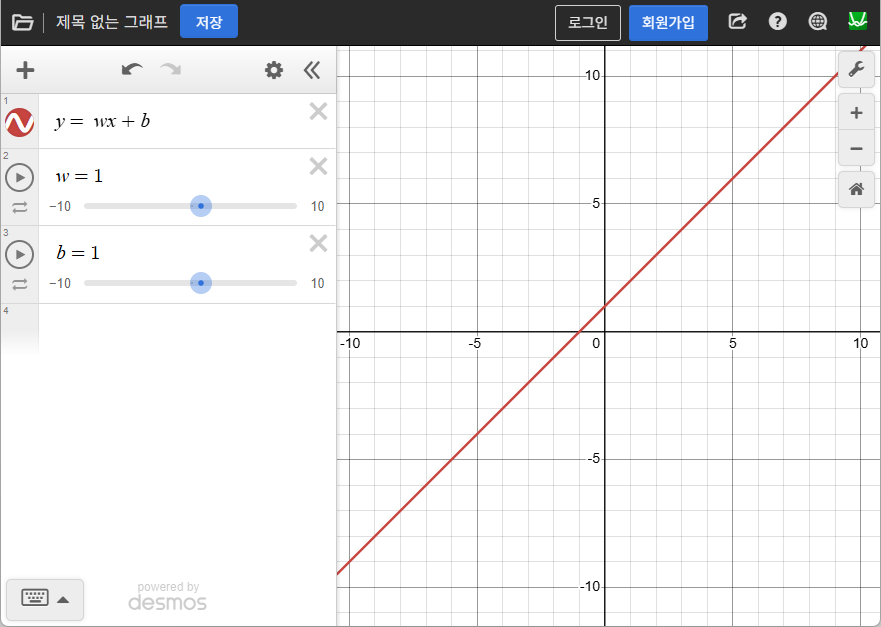

In [25]:
# 학습할 가중치, 절편(편향) 정의
# w, b의 미분값을 계산하기 때문 requires_grad=True
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# 입력데이터
x = torch.tensor(2.0)

# 정답데이터
y_true = torch.tensor(5.0)  # 실제값. 모델이 정답이 틀려야 학습가능

# 순전파 : 모델의 예측값 계산
y_pred = w * x + b
print(y_pred)

# 손실(Loss) 계산
loss = (y_pred - y_true) ** 2

print(f'예측값 : {y_pred.item()}')
print(f'손실 : {loss.item()}')

# 역전파 : 손실에 대해 w와 b의 미분값 계산
loss.backward()

# w와 b의 미분값 확인
# 기울기를 이용해서 w와 b를 업데이트하고 손실을 줄여나갈 수 있음
print(f'w의 미분값 : {w.grad}')
print(f'b의 미분값 : {b.grad}')

tensor(3., grad_fn=<AddBackward0>)
예측값 : 3.0
손실 : 4.0
w의 미분값 : -8.0
b의 미분값 : -4.0


#### 손실함수

- 오차를 숫자로 계산
    - MSE(평균제곱오차) : 예측값을 실제값으로 뺀 후 제곱승
    - MAE(평균절대오차) : 예측값과 실제값을 뺀 후 절대값의 평균

#### 학습률

- Learning rate : 얼마나 조금씩 수정할지 결정하는 값
    - 0.001 ~ 0.1 사이로 사용

#### 선형회귀 모델 구현

In [44]:
## 1. 데이터 준비
# 공부시간 x / 시험점수 정답 y
hours = torch.tensor([  
    [1.], [2.], [3.], [4.], [5.]
])  # 2차원 배열로 하는 이유 : 행렬계산 때문

scores = torch.tensor([ # 정답데이터, 실제값
    [52.], [60.], [68.], [76.], [84.]
])

## 2. 학습할 값 생성
# 학습할 파라미터
w = torch.tensor([[1.0]], requires_grad=True)   # 2차원 : 행렬곱
b = torch.tensor([0.0], requires_grad=True)     # 1차원 : 단순 더하기

## 3. 학습률 지정
learning_rate = 0.03    # 이걸 조정해야 결과가 잘 나옴

## 4. 반복학습 수행, epoch : 전체 데이터를 한번 학습한 횟수, 학습률말고는 이걸 조정해야함
for epoch in range(1001):
    
    ## 5. 예측값 계산(행렬곱)
    y_pred = hours @ w + b  # y = wx + b와 비슷함

    ## 6. 손실함수(MSE)로 손실 계산
    loss = torch.mean((y_pred - scores) ** 2)   # torch.mean() : 평균

    ## 7. 기존 미분값 초기화
    # 매번학습 전에 grad를 0으로 초기화
    # 안하면 잘못된 값으로 학습
    if w.grad is not None:
        w.grad.zero_()

    if b.grad is not None:
        b.grad.zero_()

    ## 8. 역전파 - 자동미분 계산
    loss.backward()

    ## 9. 경사하강법 - w, b 업데이트
    with torch.no_grad():   # 자동미분 엔진을 비활성화해서 필요메모리 줄이고 연산속도 증가
        # 업데이트 과정에서 계산 그래프를 기록하지 않기 위해서
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # 100번마다 출력
    if epoch % 100 == 0:
        print(f'epoch={epoch:4d}, loss={loss.item():.4f}, w={w.item():.4f}, b={b.item():.4f}')

# 최종결과
print('\n최종학습결과')
print(f'기울기 w = {w.item():.4f}')
print(f'절편 b = {b.item():.4f}')

## 10. 테스트 수행
test_hours = torch.tensor([
    [6.], [7.], [8.]
])

with torch.no_grad():
    pred_scores = test_hours @ w + b

print('\n예측결과')
for h, s in zip(test_hours, pred_scores):   # 하나씩 끄집어내서 하나의 튜플로 만들기
    print(f'{h.item():.0f}시간 공부 -> 예상점수 {s.item():.2f}')

epoch=   0, loss=4323.0000, w=13.5400, b=3.9000
epoch= 100, loss=36.1552, w=11.8642, b=30.0491
epoch= 200, loss=4.7062, w=9.3941, b=38.9667
epoch= 300, loss=0.6126, w=8.5030, b=42.1841
epoch= 400, loss=0.0797, w=8.1815, b=43.3448
epoch= 500, loss=0.0104, w=8.0655, b=43.7636
epoch= 600, loss=0.0014, w=8.0236, b=43.9147
epoch= 700, loss=0.0002, w=8.0085, b=43.9692
epoch= 800, loss=0.0000, w=8.0031, b=43.9889
epoch= 900, loss=0.0000, w=8.0011, b=43.9960
epoch=1000, loss=0.0000, w=8.0004, b=43.9985

최종학습결과
기울기 w = 8.0004
절편 b = 43.9985

예측결과
6시간 공부 -> 예상점수 92.00
7시간 공부 -> 예상점수 100.00
8시간 공부 -> 예상점수 108.00


- learning_rate를 계속 변경하면서 최적의 모델 찾기
- 0.1, 0.01, 0.001등과 같은 반복테스트 후 
- 0.03이 가장 최적의 learning_rate임을 확인
- 7시간 공부하면 100점

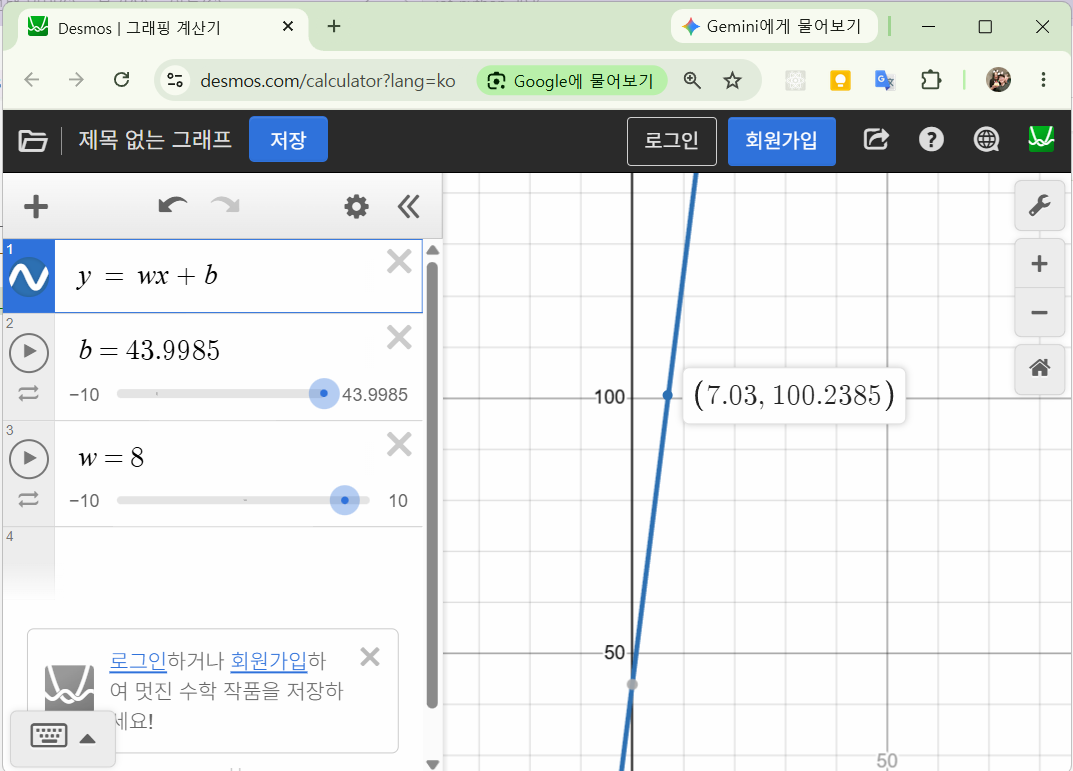

#### PyTorch 모델 사용하기

- PyTorch 모듈 사용 모델 생성
    1. 데이터 준비
    2. 모델 설계 - PyTorch 클래스 활용
    3. 손실함수 - PyTorch 손실함수 활용
    4. 옵티마이저 - PyTorch 옵티마이저 활용
    5. 모델 학습
    6. 모델 테스트

In [ ]:
# 필요 라이브러리 추가
import torch
import torch.nn as nn   # 신경망 모듈
import torch.optim as optim     # 손실함수, 최적화 알고리즘 모듈

# y = 2x + 1

# 1. 데이터 준비
# 결과를 유사하게 만들 랜덤시드 설정
torch.manual_seed(42)

w_true = 2.0
b_true = 1.0

# 100개의 랜덤값 x를 생성
x = torch.randn(100) * 10

# 노이즈 생성 / 실제와 유사하게 오차, 근사값이 나오도록 추가한 값 - 없어도 상관없음
noise = torch.randn(100) * 2    # (100, ) 데이터 100개가 들어감

# y값 생성 : y = 2x + 1 + noise
y = w_true * x + b_true + noise

# 2. 모델 설계 :클래스로 생성. nn Module클래스 상속
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()

        # 학습 파라미터 w 
        # 최초 랜덤값으로 시작
        self.w = nn.Parameter(torch.randn(1))

        # 학습 파라미터 b
        self.b = nn.Parameter(torch.randn(1))

    def forward(self, x):
        # 선형회귀 공식 y = wx + b
        y_pred = self.w * x + self.b    # 순전파 공식

        return y_pred

# 모델 객체 생성
model = LinearRegression()

# 3. 손실함수
# MSE - 예측값과 실제값 차이를 제곱하고 평균
loss_fn = nn.MSELoss()

# 4. 옵티마이저
# SGD(확률적 경사 하강법)
# model.parameters() w, b
# lr(learning rate)
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 5. 모델학습
num_epochs = 1000

for epoch in range(num_epochs + 1):
    # 1) 순전파
    # 현재 w, b로 예측값 계산
    y_pred = model(x)

    # 2) 순실계산
    # 예측값, 실제값 차이 계산
    loss = loss_fn(y_pred, y)

    # 3) 기존 기울기 초기화
    # PyTorch는 기울기 누적함. 매번 0으로 초기화
    optimizer.zero_grad()

    # 4) 역전파
    # loss를 기준으로 w, b의 미분값 계산
    loss.backward()

    # 5) 파라미터 업데이트
    # 계산된 미분값 이용, w, b 조금씩 수정
    optimizer.step()

    # 100번마다 학습상태 출력
    if (epoch+1) % 100 == 0:
        print(f'epoch={epoch+1:4d}, loss={loss.item():.4f}, w={model.w.item():.4f}, b={model.b.item():.4f}')


# 6. 모델 평가
print('\n----최종 파라미터----')
print(f'학습된 w : {model.w.item():.4f}')
print(f'학습된 b : {model.b.item():.4f}')
print('\n---------------------')
print(f'실제 w : {w_true}')
print(f'실제 b : {b_true}')

# 7. 예측 테스트
test_x = torch.tensor([5.0, 10.0, 15.0])

with torch.no_grad():
    test_y_pred = model(test_x)

    print('\n=== 예측 결과 ===')
    for x, y in zip(test_x, test_y_pred):
        print(f'x = {x.item():.1f} -> 예측 y = {y.item():.4f}')

epoch= 100, loss=3.1519, w=2.0017, b=0.9008
epoch= 200, loss=3.1220, w=2.0025, b=1.0486
epoch= 300, loss=3.1215, w=2.0024, b=1.0683
epoch= 400, loss=3.1214, w=2.0024, b=1.0709
epoch= 500, loss=3.1214, w=2.0024, b=1.0713
epoch= 600, loss=3.1214, w=2.0024, b=1.0713
epoch= 700, loss=3.1214, w=2.0024, b=1.0713
epoch= 800, loss=3.1214, w=2.0024, b=1.0713
epoch= 900, loss=3.1214, w=2.0024, b=1.0713
epoch=1000, loss=3.1214, w=2.0024, b=1.0713

----최종 파라미터----
학습된 w : 2.0024
학습된 b : 1.0713

---------------------
실제 w : 2.0
실제 b : 1.0

=== 예측 결과 ===
x = 5.0 -> 예측 y = 11.0832
x = 10.0 -> 예측 y = 21.0950
x = 15.0 -> 예측 y = 31.1068


#### 다중 퍼셉트론 예제

In [92]:
# 필요 라이브러리 추가
import torch
import torch.nn as nn   # 신경망 모듈
import torch.optim as optim     # 손실함수, 최적화 알고리즘 모듈

# y = 2x + 1

# 1. 데이터 준비
# 결과를 유사하게 만들 랜덤시드 설정
torch.manual_seed(42)

w_true = 2.0
b_true = 1.0

# 100개의 랜덤값 x를 생성
X = torch.randn(100, 1) * 10    # 다중 퍼셉트론이기 때문에 매트릭스형태로 넣어야됨(100)이 아닌 (100, 1)

# y값 생성 : y = 2x + 1
Y = w_true * X + b_true

# 2. 다중 퍼셉트론 모델 설계
class NLPRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            # 입력층 1개 -> 1st 은닉층 16개(2^n)
            nn.Linear(in_features=1, out_features=16),
            # 활성화 함수
            nn.ReLU(),
            # 1st 은닉층 16개 -> 2nd 은닉층 8개
            # 위의 출력층에서 16개로 분리되었는데 현재 입력층에서 16개로 입력받지 않으면 오류발생!
            nn.Linear(in_features=16, out_features=8),
            nn.ReLU(),
            # 2nd 은닉층 8개 -> 출력층 1개
            nn.Linear(in_features=8, out_features=1)
        )

    def forward(self, x):
        return self.model(x)
    
# 3. 모델 생성
model = NLPRegression()

# 4. 손실 함수 - 중요
loss_fn = nn.MSELoss()  # 평균제곱곱차, 연속적인 값일 때 이거씀

# 5. 옵티마이저 - 중요(현재 Adam보다 SGD가 정확)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 6. 학습
num_epochs = 2000
for epoch in range(num_epochs):
    # 1) 순전파
    y_pred = model(X)

    # 2) 손실 계산
    loss = loss_fn(y_pred, Y)

    # 3) 기존 기울기 초기화
    optimizer.zero_grad()

    # 4) 역전파
    loss.backward()

    # 5) 파라미터 업데이트
    optimizer.step()

    # 100번마다 출력
    if (epoch + 1) % 100 == 0:
        print(
            f'epoch={epoch + 1:4d},'
            f'loss={loss.item():.6f}'
        )

# 7. 예측 테스트
test_x = torch.tensor([[5.0], [10.0], [15.0]])

with torch.no_grad():
    test_y_pred = model(test_x)

print('\n=== 예측결과 ===')
for x, y in zip(test_x, test_y_pred):
    print(f'x = {x.item():.1f} -> 예측 y = {y.item():.4f}')

# 8. 실제 정답과 비교
print('\n=== 실제 정답 ===')
for x in test_x:
    true_y = w_true * x + b_true
    print(f'x = {x.item():.1f} -> 실제 y = {true_y.item():.4f}')

epoch= 100,loss=0.162333
epoch= 200,loss=0.051195
epoch= 300,loss=0.013114
epoch= 400,loss=0.003995
epoch= 500,loss=0.002230
epoch= 600,loss=0.001695
epoch= 700,loss=0.001380
epoch= 800,loss=0.001158
epoch= 900,loss=0.000993
epoch=1000,loss=0.000868
epoch=1100,loss=0.000767
epoch=1200,loss=0.000688
epoch=1300,loss=0.000620
epoch=1400,loss=0.000558
epoch=1500,loss=0.000500
epoch=1600,loss=0.000447
epoch=1700,loss=0.000397
epoch=1800,loss=0.000351
epoch=1900,loss=0.000308
epoch=2000,loss=0.000269

=== 예측결과 ===
x = 5.0 -> 예측 y = 10.9959
x = 10.0 -> 예측 y = 20.9984
x = 15.0 -> 예측 y = 31.0008

=== 실제 정답 ===
x = 5.0 -> 실제 y = 11.0000
x = 10.0 -> 실제 y = 21.0000
x = 15.0 -> 실제 y = 31.0000
